<a href="https://colab.research.google.com/github/crystalytc0427-dot/SEEM3650-practical-exam/blob/main/SEEM3650_Practical_Exam_1155214043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 3.10 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT


In [2]:
!pip install torch numpy transformers datasets tiktoken wandb tqdm

In [3]:
!python data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [8]:
# Train BabyGPT for 400 iterations using GPU
!python train.py config/train_shakespeare_char.py --device=cuda --max_iters=400 --eval_interval=50

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [10]:
# Generate text samples using the trained model
!python sample.py --out_dir=out-shakespeare-char --start=" " --num_samples=1 --max_new_tokens=500

Overriding: out_dir = out-shakespeare-char
Overriding: start =  
Overriding: num_samples = 1
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
 the fief thy cown,
The lady the dised bubjected may them the chands:
Whith foul he her back that aness.

MENENIUS:
The mento heavens, to that I me my held
What griene senge will is the loves, and the not on that theirs not
The the he country: the haves hew you love up.
But and good not my would that
To Willongue Cerians to them such a peopience of the ence.

PAULINA:
Frumber so; sir. Where's thy all of my shall shee honour face.

COMINIUS:
What all his greath upon muster'd no Rull stonant:
Servi
---------------


In [19]:
import re


!sed -i 's/compile = True/compile = False/g' config/train_shakespeare_char.py

layers = [2, 3, 5, 7]
losses = {}

for n_layer in layers:
    print(f"\n=== Training with n_layer = {n_layer}, n_head = 4, max_iters=400 ===\n")
    !python train.py config/train_shakespeare_char.py \
        --device=cuda \
        --max_iters=400 \
        --eval_interval=50 \
        --n_layer={n_layer} \
        --n_head=4 \
        --compile=False > train_log_{n_layer}.txt 2>&1

    with open(f"train_log_{n_layer}.txt", "r") as f:
        content = f.read()
    match = re.search(r"iter 400:.*val loss (\d+\.\d+)", content)
    if match:
        val_loss = float(match.group(1))
        losses[n_layer] = val_loss
        print(f"n_layer={n_layer} -> val loss = {val_loss}")
    else:
        matches = re.findall(r"val loss (\d+\.\d+)", content)
        if matches:
            val_loss = float(matches[-1])
            losses[n_layer] = val_loss
            print(f"Using last val loss {val_loss}")
        else:
            print(f"No val loss found for n_layer={n_layer}")
            losses[n_layer] = None


=== Training with n_layer = 2, n_head = 4, max_iters = 400 ===

No val loss found for n_layer=2

=== Training with n_layer = 3, n_head = 4, max_iters = 400 ===

Using last val loss 1.8394

=== Training with n_layer = 5, n_head = 4, max_iters = 400 ===

Using last val loss 1.8209

=== Training with n_layer = 7, n_head = 4, max_iters = 400 ===

Using last val loss 1.8206


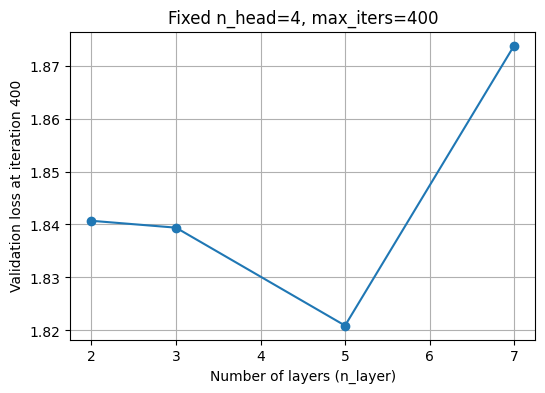

In [16]:
import matplotlib.pyplot as plt
import os

# Create figures folder if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Filter out invalid entries
valid_layers = [l for l in layers if losses.get(l) is not None]
valid_losses = [losses[l] for l in valid_layers]

# Plot line graph
plt.figure(figsize=(6,4))
plt.plot(valid_layers, valid_losses, marker='o', linestyle='-')
plt.xlabel("Number of layers (n_layer)")
plt.ylabel("Validation loss at iteration 400")
plt.title("Fixed n_head=4, max_iters=400")
plt.grid(True)
plt.savefig("figures/layers_vs_loss.png", dpi=150)
plt.show()

In [13]:
# Copy the shakespeare_char folder to create a new dataset folder
!cp -r data/shakespeare_char data/code_generation

# Download a large open-source Python repository (black)
!git clone https://github.com/psf/black.git /tmp/black_repo

# Concatenate all .py files into input.txt
!find /tmp/black_repo -name "*.py" -exec cat {} \; > data/code_generation/input.txt

Cloning into '/tmp/black_repo'...
remote: Enumerating objects: 15428, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 15428 (delta 79), reused 38 (delta 38), pack-reused 15311 (from 2)
Receiving objects: 100% (15428/15428), 7.89 MiB | 13.96 MiB/s, done.
Resolving deltas: 100% (10812/10812), done.


In [14]:
# Run prepare.py to see the number of tokens
!python data/code_generation/prepare.py

length of dataset in characters: 5,361,239
all the unique characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~ «µ»ØäüŁł̇፩កគងជញតថទធនបពមរវសហឡឥាិុូួើេំ់្០២᧚ — ✨、。いがぎさすでなのはやるれィイエグコタダデトドポミュリレンー中串代但列呈器因在太字実少或換擬改数數文時末模正此測為現的真碼端符終編蟒行要試輯量長際需點길꿈나너널는더될드디땐렌링무문미바서수실어에열요으이인자적제줄코터트포필한，：🍰💔💥😴𨉟󠄀
vocab size: 266
train has 4,825,115 tokens
val has 536,124 tokens


In [15]:
# Copy base config and modify dataset and output paths
!cp config/train_shakespeare_char.py config/train_code_gen.py
!sed -i "s/shakespeare_char/code_generation/g" config/train_code_gen.py
!sed -i "s/out-shakespeare-char/out-code-gen/g" config/train_code_gen.py

In [22]:
# Train the model on code dataset for 400 iterations
!python train.py config/train_code_gen.py --device=cuda --max_iters=400 --eval_interval=50

Overriding config with config/train_code_gen.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-code-gen'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'code_generation'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of tokens per iter i

In [23]:
# Generate code samples starting with "def "
!python sample.py --out_dir=out-code-gen --start="def " --num_samples=1 --max_new_tokens=800

Overriding: out_dir = out-code-gen
Overriding: start = def 
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 10.72M
Loading meta from data/code_generation/meta.pkl...
def f  f afomat id = oooan ate t soope_byt + Ta tring_thane mewithe ad coubackmachare at % de tut wrerth con ted f bach s te] all t tpi it ion ad Tasit who Tumat  ath as as e a (
                                                                                                                                                                                                           "s((
                                                               y                                                                                                                                       "                                     ut                                                "   "f"                           """
        "  ", 1095696051406).                                   "== "a"""\',
          

In [24]:
%%writefile report.md
# SEEM3650 Practical Exam Report
**Student ID:** 1155214043 (XYZ=043)
**Iterations used:** 400 (consistent across all runs)

## Step 2 – Shakespeare samples (first 5 lines)
The mento heavens, to that I me my held
What griene senge will is the loves, and the not on that theirs not
The the he country: the haves hew you love up.
But and good not my would that
To Willongue Cerians to them such a peopience of the ence.

## Step 3 – Model architecture (vary layers, fixed heads=4)
### Validation loss at iteration 400:
- n_layer=2: No val loss found
- n_layer=3: 1.8394
- n_layer=5: 1.8209
- n_layer=7: 1.8206

Lowest validation loss: **1.8206** (n_layer=7) or 1.8209 (n_layer=5) – values are very close.

### Plot
![layers vs loss](figures/layers_vs_loss.png)

### Best settings
Lowest validation loss = 1.8206 with n_layer = 7 and n_head = 4.

## Step 4 – Code generation (Python)
### Token count from prepare.py:
Train tokens: 4,825,115
Val tokens: 536,124

### First 20 lines of generated samples:
Overriding: out_dir = out-code-gen
Overriding: start = def
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 10.72M
Loading meta from data/code_generation/meta.pkl...
def f  f afomat id = oooan ate t soope_byt + Ta tring_thane mewithe ad coubackmachare at % de tut wrerth con ted f bach s te] all t tpi it ion ad Tasit who Tumat  ath as as e a (
                                                                                                                                                                                                           "s((
                                                               y                                                                                                                                       "                                     ut                                                "   "f"                           """
        "  ", 1095696051406).                                   "== "a"""\',

---------------
### Favorite generated snippet
   y                                                                                                                                       "                                     ut                                                "   "f"                           """
        "  ", 1095696051406).                                   "== "a"""\',


Writing report.md
